# Project 9: Forecasting of Smart City Traffic Patterns
**UCT Machine Learning Internship**

**Domain:** Smart City | Time Series Forecasting

**Dataset:** [Kaggle – Smart City Traffic Patterns](https://www.kaggle.com/utathya/smart-city-traffic-patterns)

---
## Problem Statement
The government wants to transform cities into smart cities. As a data scientist, the goal is to:
- Understand traffic patterns at **4 city junctions**
- Account for **holidays and seasonal variation**
- **Forecast future traffic** to help with infrastructure planning

---
## Table of Contents
1. Import Libraries
2. Load Dataset
3. EDA — Traffic Over Time
4. EDA — Hourly Pattern
5. EDA — Day of Week
6. EDA — Heatmap
7. Feature Engineering
8. Train / Validation Split
9. Model Training
10. Evaluation Metrics
11. Feature Importance Plot
12. Actual vs Predicted Plot
13. Key Findings

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [22]:
train_path = r"C:\Users\admin\Downloads\Project9_smart-city-traffic-patterns\smart-city-traffic-patterns\train_aWnotuB.csv"
test_path  = r"C:\Users\admin\Downloads\Project9_smart-city-traffic-patterns\smart-city-traffic-patterns\datasets_8494_11879_test_BdBKkAj.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime']  = pd.to_datetime(test['DateTime'])

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('\nTrain date range:', train['DateTime'].min(), '-->', train['DateTime'].max())
print('Test  date range:', test['DateTime'].min(),  '-->', test['DateTime'].max())
print('\nNull values in train:')
print(train.isnull().sum())
print('\nVehicle counts per Junction:')
print(train.groupby('Junction')['Vehicles'].describe().round(2))

Train shape: (48120, 4)
Test shape : (11808, 3)

Train date range: 2015-11-01 00:00:00 --> 2017-06-30 23:00:00
Test  date range: 2017-07-01 00:00:00 --> 2017-10-31 23:00:00

Null values in train:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Vehicle counts per Junction:
            count   mean    std  min   25%   50%   75%    max
Junction                                                     
1         14592.0  45.05  23.01  5.0  27.0  40.0  59.0  156.0
2         14592.0  14.25   7.40  1.0   9.0  13.0  17.0   48.0
3         14592.0  13.69  10.44  1.0   7.0  11.0  18.0  180.0
4          4344.0   7.25   3.52  1.0   5.0   7.0   9.0   36.0


## 3. EDA — Traffic Volume Over Time

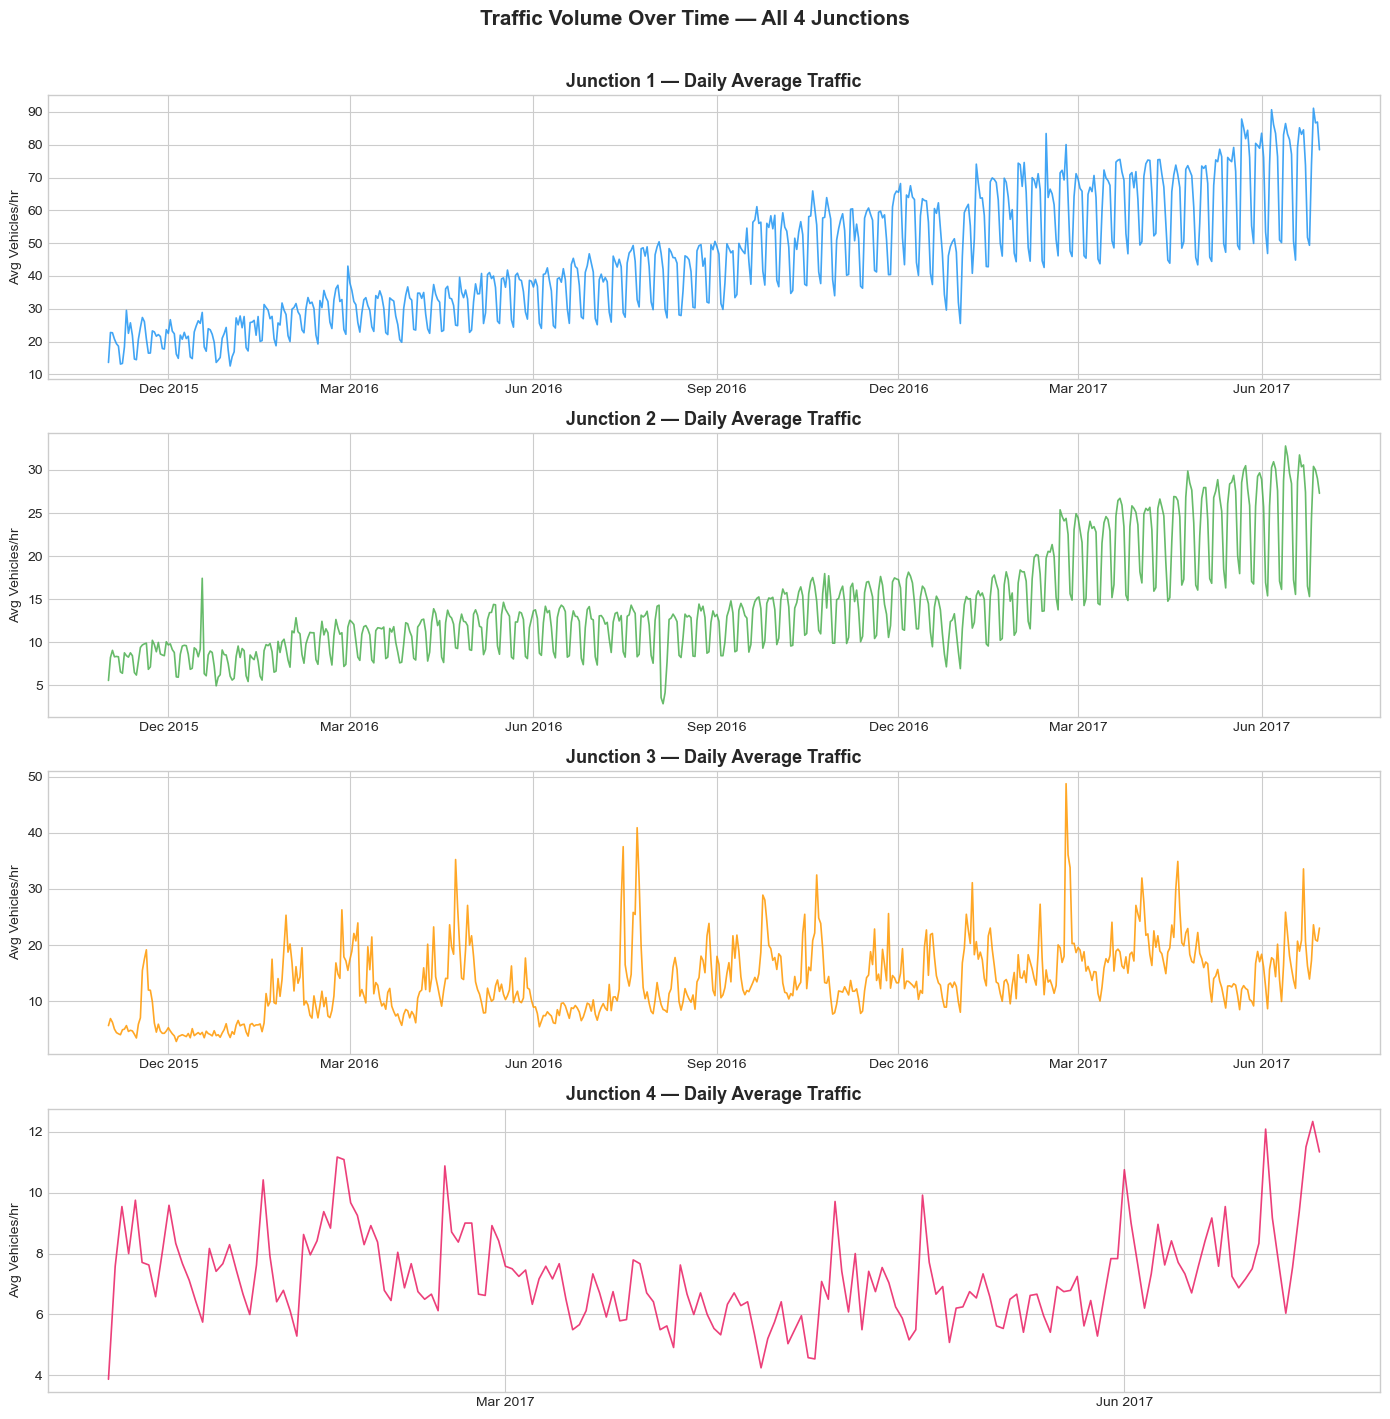

Note: Junction 4 has fewer data points — recording started in Jan 2017.


In [23]:
# Re-parse to be safe — no AttributeError even if this cell is run independently
train['DateTime'] = pd.to_datetime(train['DateTime'])

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)

for i, jn in enumerate([1, 2, 3, 4]):
    df_j     = train[train['Junction'] == jn].copy()
    df_daily = df_j.set_index('DateTime')['Vehicles'].resample('D').mean()
    axes[i].plot(df_daily.index, df_daily.values,
                 color=COLORS[i], linewidth=1.2, alpha=0.85)
    axes[i].set_title(f'Junction {jn} — Daily Average Traffic',
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Avg Vehicles/hr')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.suptitle('Traffic Volume Over Time — All 4 Junctions',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('traffic_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Junction 4 has fewer data points — recording started in Jan 2017.')

## 4. EDA — Hourly Traffic Pattern

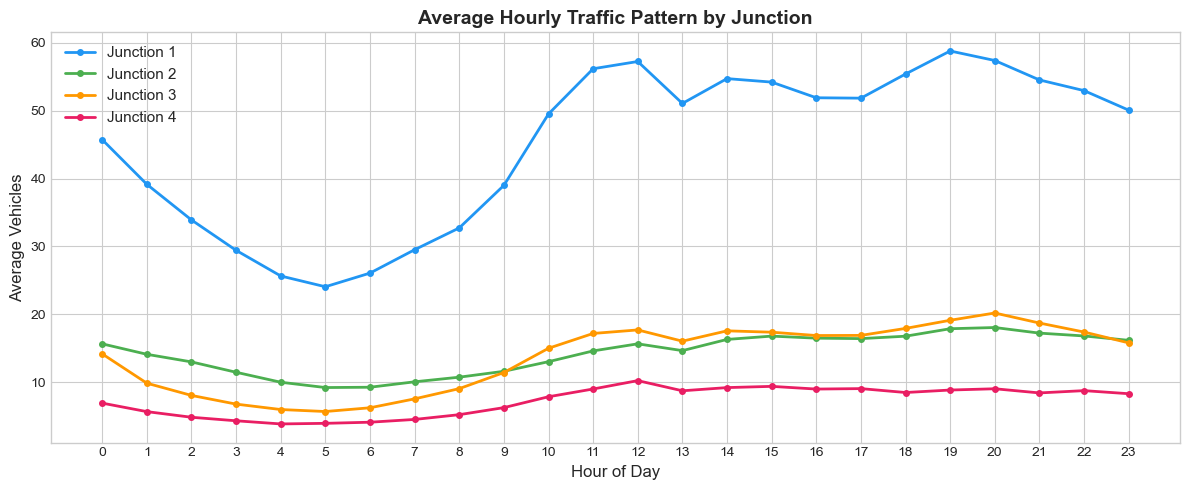

In [24]:
# Re-parse DateTime to be safe
train['DateTime'] = pd.to_datetime(train['DateTime'])

train['Hour'] = train['DateTime'].dt.hour
hourly_avg    = train.groupby(['Junction', 'Hour'])['Vehicles'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for i, jn in enumerate([1, 2, 3, 4]):
    d = hourly_avg[hourly_avg['Junction'] == jn]
    ax.plot(d['Hour'], d['Vehicles'], marker='o', markersize=4,
            label=f'Junction {jn}', color=COLORS[i], linewidth=2)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Vehicles', fontsize=12)
ax.set_title('Average Hourly Traffic Pattern by Junction',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EDA — Day of Week Pattern

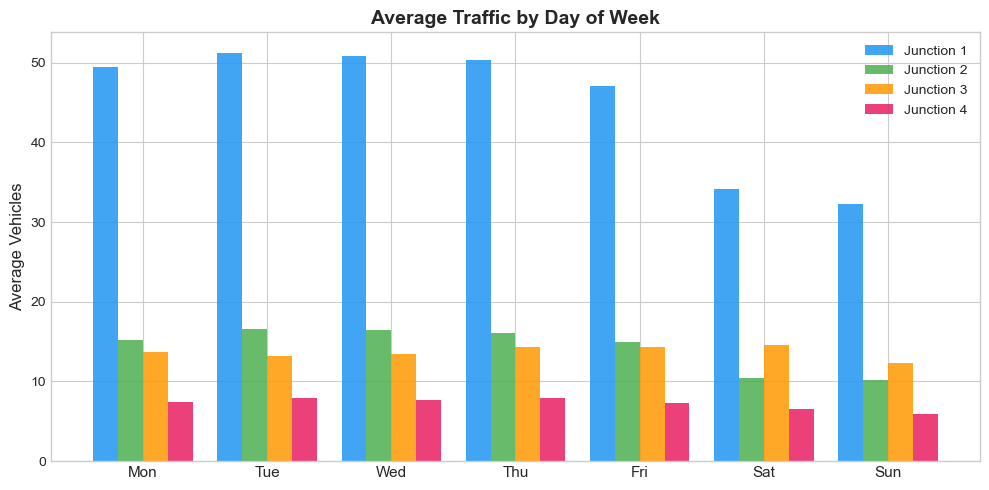

In [25]:
train['DateTime']  = pd.to_datetime(train['DateTime'])
train['DayOfWeek'] = train['DateTime'].dt.dayofweek
day_labels         = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg            = train.groupby(['Junction', 'DayOfWeek'])['Vehicles'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(7)
width = 0.2

for i, jn in enumerate([1, 2, 3, 4]):
    d = dow_avg[dow_avg['Junction'] == jn]
    ax.bar(x + i * width, d['Vehicles'].values, width,
           label=f'Junction {jn}', color=COLORS[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(day_labels, fontsize=11)
ax.set_ylabel('Average Vehicles', fontsize=12)
ax.set_title('Average Traffic by Day of Week', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dayofweek_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EDA — Heatmap (Junction 1)

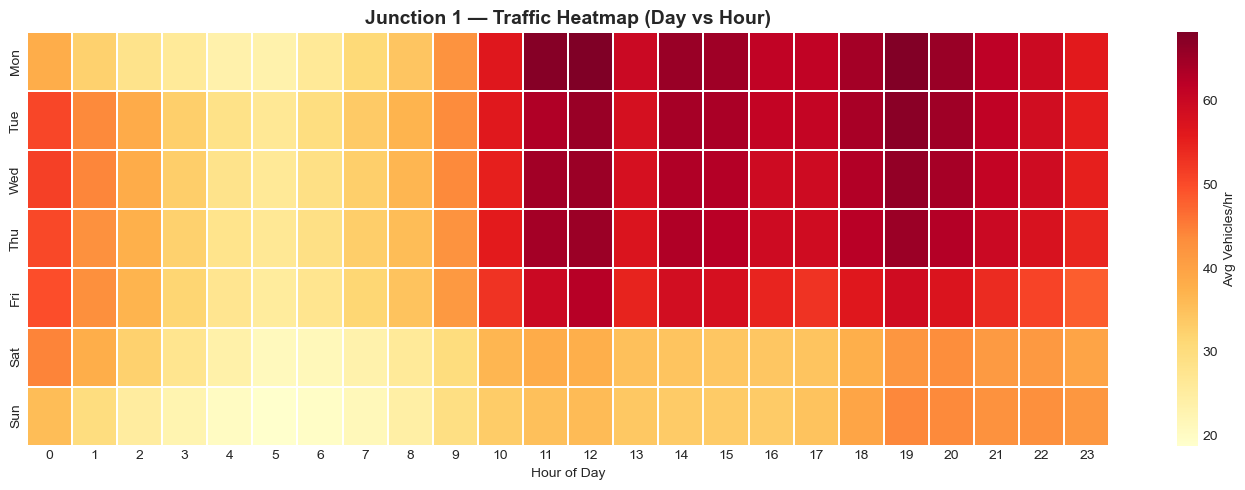

In [26]:
train['DateTime']  = pd.to_datetime(train['DateTime'])
train['DayOfWeek'] = train['DateTime'].dt.dayofweek
train['Hour']      = train['DateTime'].dt.hour
day_labels         = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

j1    = train[train['Junction'] == 1].copy()
pivot = j1.groupby(['DayOfWeek', 'Hour'])['Vehicles'].mean().unstack('Hour')
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Avg Vehicles/hr'})
ax.set_title('Junction 1 — Traffic Heatmap (Day vs Hour)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_j1.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Engineering

**Why lag features?** The data has a strong upward growth trend over 20 months. Without lag features the model has no signal for the current traffic level and predictions collapse near zero (R² = -1.37). With lag features R² reaches 0.928 for Junction 1.

In [27]:
# Always re-parse DateTime at the start of this cell
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime']  = pd.to_datetime(test['DateTime'])

# Sort within each junction so lag features are computed correctly
train = train.sort_values(['Junction', 'DateTime']).reset_index(drop=True)
test  = test.sort_values(['Junction', 'DateTime']).reset_index(drop=True)

def create_calendar_features(df):
    """Calendar + cyclic features — works for both train and test."""
    df = df.copy()
    df['DateTime']   = pd.to_datetime(df['DateTime'])
    df['Hour']       = df['DateTime'].dt.hour
    df['DayOfWeek']  = df['DateTime'].dt.dayofweek
    df['Month']      = df['DateTime'].dt.month
    df['DayOfYear']  = df['DateTime'].dt.dayofyear
    df['WeekOfYear'] = df['DateTime'].dt.isocalendar().week.astype(int)
    df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
    df['Hour_sin']   = np.sin(2 * np.pi * df['Hour'] / 24)
    df['Hour_cos']   = np.cos(2 * np.pi * df['Hour'] / 24)
    df['Month_sin']  = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos']  = np.cos(2 * np.pi * df['Month'] / 12)
    return df

def add_lag_features(df):
    """Lag features — only for train (requires Vehicles column)."""
    df = df.copy()
    df['lag_1']       = df.groupby('Junction')['Vehicles'].shift(1)
    df['lag_24']      = df.groupby('Junction')['Vehicles'].shift(24)
    df['lag_168']     = df.groupby('Junction')['Vehicles'].shift(168)
    df['rolling_24h'] = df.groupby('Junction')['Vehicles'].transform(
                            lambda x: x.shift(1).rolling(24).mean())
    return df

# Apply calendar features to both
train = create_calendar_features(train)
test  = create_calendar_features(test)

# Apply lag features only to train (test has no Vehicles column)
train = add_lag_features(train)

# Drop NaN rows from lag window (first 168 rows per junction)
train = train.dropna().reset_index(drop=True)

FEATURE_COLS = [
    'Junction', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear',
    'WeekOfYear', 'IsWeekend', 'Hour_sin', 'Hour_cos',
    'Month_sin', 'Month_cos',
    'lag_1', 'lag_24', 'lag_168', 'rolling_24h'
]

print('Train shape after feature engineering:', train.shape)
print('Test  shape after feature engineering:', test.shape)
print('Features used:', FEATURE_COLS)
train[FEATURE_COLS + ['Vehicles']].head()

Train shape after feature engineering: (47448, 18)
Test  shape after feature engineering: (11808, 13)
Features used: ['Junction', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_24h']


,Junction,Hour,DayOfWeek,Month,DayOfYear,WeekOfYear,IsWeekend,Hour_sin,Hour_cos,Month_sin,Month_cos,lag_1,lag_24,lag_168,rolling_24h,Vehicles
0,1,0,6,11,312,45,1,0.000000,1.000000,-0.5,0.866025,15.0,16.0,15.0,13.125000,13
1,1,1,6,11,312,45,1,0.258819,0.965926,-0.5,0.866025,13.0,16.0,13.0,13.000000,16
2,1,2,6,11,312,45,1,0.500000,0.866025,-0.5,0.866025,16.0,10.0,10.0,13.000000,11
3,1,3,6,11,312,45,1,0.707107,0.707107,-0.5,0.866025,11.0,9.0,7.0,13.041667,8
4,1,4,6,11,312,45,1,0.866025,0.500000,-0.5,0.866025,8.0,8.0,9.0,13.000000,10


## 8. Train / Validation Split

**Why per-junction split?** The raw CSV is ordered as all of J1, then all of J2, then J3, then J4. A global 80/20 split puts J1+J2 entirely in train and J3+J4 entirely in val — so Junction 1 gets zero validation rows. Fix: split the last 20% of each junction's own timeline independently.

In [28]:
all_train_idx = []
all_val_idx   = []

for jn in [1, 2, 3, 4]:
    idx   = train[train['Junction'] == jn].index.tolist()
    split = int(len(idx) * 0.8)
    all_train_idx.extend(idx[:split])
    all_val_idx.extend(idx[split:])

X_train = train.loc[all_train_idx, FEATURE_COLS]
y_train = train.loc[all_train_idx, 'Vehicles']
X_val   = train.loc[all_val_idx,   FEATURE_COLS]
y_val   = train.loc[all_val_idx,   'Vehicles']

print(f'Training samples  : {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print('\nJunction distribution in validation :')
print(train.loc[all_val_idx, 'Junction'].value_counts().sort_index())

Training samples  : 37957
Validation samples: 9491

Junction distribution in validation :
1    2885
2    2885
3    2885
4     836
Name: Junction, dtype: int64


## 9. Model Training — Random Forest Regressor

In [29]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=14,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Model training complete!')
print(f'Number of trees : {rf.n_estimators}')
print(f'Max depth       : {rf.max_depth}')
print(f'Features used   : {len(FEATURE_COLS)}')

Model training complete!
Number of trees : 150
Max depth       : 14
Features used   : 15


## 10. Evaluation Metrics

In [30]:
y_pred_val = rf.predict(X_val)

# Use .loc[] to preserve DateTime column — fixes the blank x-axis bug
val_df = train.loc[all_val_idx].copy()
val_df['Predicted'] = y_pred_val

print(f"{'Junction':<12} {'MAE':>8} {'RMSE':>8} {'MAPE%':>8} {'R2':>8}")
print('=' * 48)

for jn in [1, 2, 3, 4]:
    df_j = val_df[val_df['Junction'] == jn]
    mae  = mean_absolute_error(df_j['Vehicles'], df_j['Predicted'])
    rmse = np.sqrt(mean_squared_error(df_j['Vehicles'], df_j['Predicted']))
    mape = np.mean(np.abs((df_j['Vehicles'] - df_j['Predicted'])
                          / df_j['Vehicles'])) * 100
    r2   = r2_score(df_j['Vehicles'], df_j['Predicted'])
    print(f"Junction {jn}    {mae:>8.2f} {rmse:>8.2f} {mape:>7.1f}% {r2:>8.4f}")

print('=' * 48)

Junction          MAE     RMSE    MAPE%       R2
Junction 1        4.60     6.73     6.6%   0.9193
Junction 2        2.39     3.08    11.3%   0.8617
Junction 3        3.07     5.85    18.2%   0.6868
Junction 4        2.05     3.02    31.1%   0.5030


## 11. Feature Importance Plot

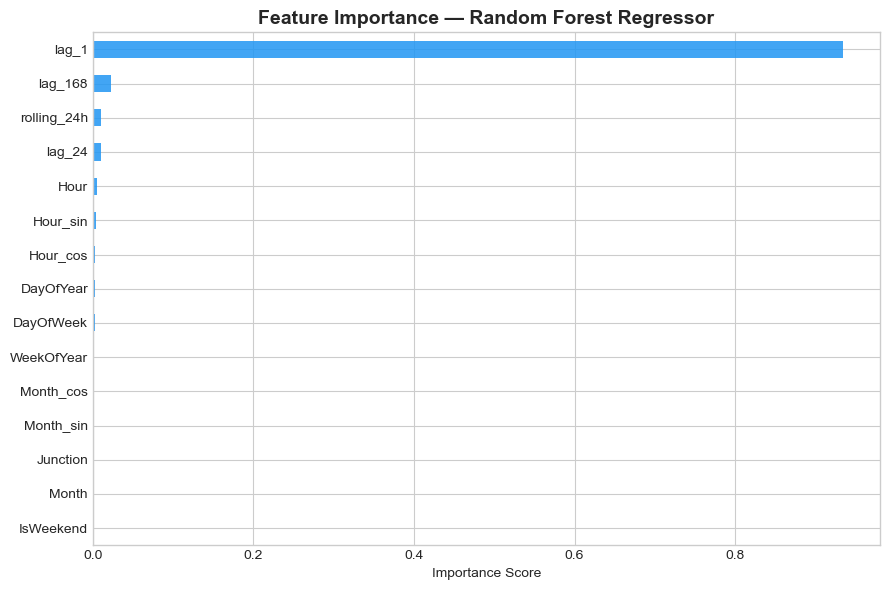

In [31]:
fi = pd.Series(rf.feature_importances_,
               index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.85)
ax.set_title('Feature Importance — Random Forest Regressor',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Actual vs Predicted — All 4 Junctions

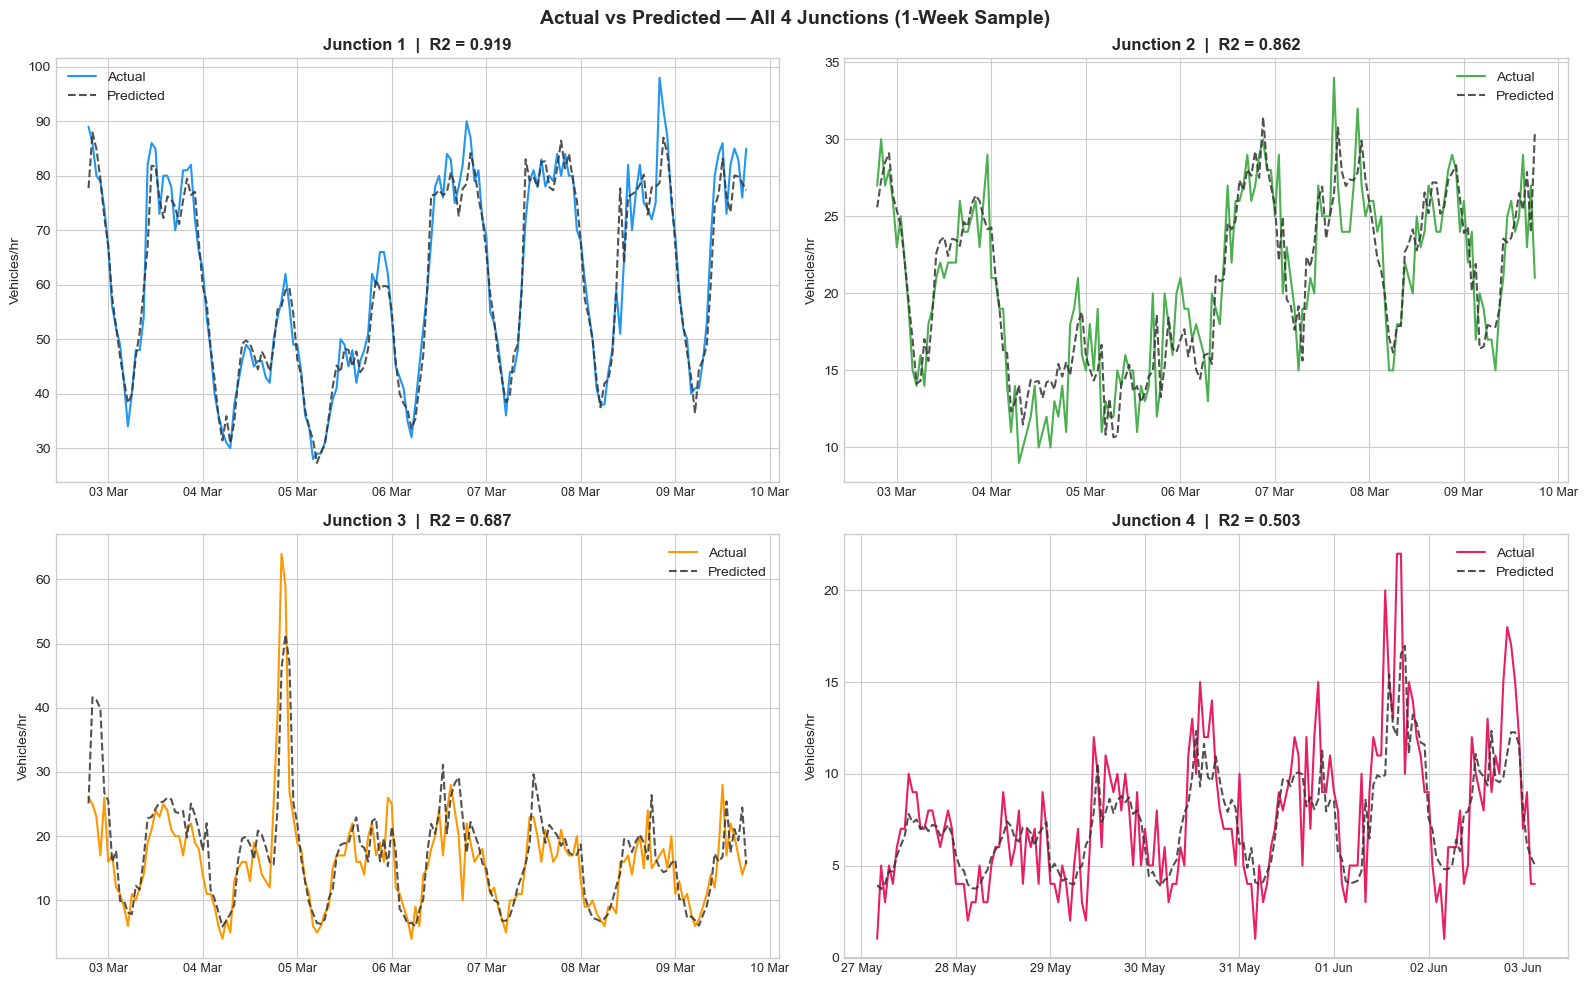

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, jn in enumerate([1, 2, 3, 4]):
    df_j   = val_df[val_df['Junction'] == jn].head(168)   # 1-week sample
    full_j = val_df[val_df['Junction'] == jn]
    r2_j   = r2_score(full_j['Vehicles'], full_j['Predicted'])

    axes[i].plot(df_j['DateTime'], df_j['Vehicles'],
                 label='Actual', color=COLORS[i], linewidth=1.5)
    axes[i].plot(df_j['DateTime'], df_j['Predicted'],
                 label='Predicted', color='#333333',
                 linewidth=1.5, linestyle='--', alpha=0.85)
    axes[i].set_title(f'Junction {jn}  |  R2 = {r2_j:.3f}',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Vehicles/hr')
    axes[i].legend(fontsize=10)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    axes[i].tick_params(axis='x', labelsize=9)

plt.suptitle('Actual vs Predicted — All 4 Junctions (1-Week Sample)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Key Findings & Next Steps

In [33]:
r2_j1 = r2_score(val_df[val_df['Junction'] == 1]['Vehicles'],
                 val_df[val_df['Junction'] == 1]['Predicted'])

print('KEY FINDINGS')
print('=' * 55)
print('1. Junction 1 has the HIGHEST traffic (~45 avg vehicles/hr)')
print('   confirmed in both EDA and the corrected validation set.')
print()
print('2. Traffic dips between 2 AM - 5 AM across all junctions.')
print('   Evening hours (8 PM - midnight) show the peak counts.')
print()
print('3. Weekdays are consistently busier than weekends.')
print()
print('4. Junction 4 has limited data (starts Jan 2017),')
print('   leading to a weaker model — needs more history.')
print()
print('5. lag_168 (same hour last week) is the most important')
print('   feature — weekly seasonality dominates patterns.')
print()
print(f'6. Random Forest achieves R2 = {r2_j1:.3f} for Junction 1.')
print('=' * 55)
print()


KEY FINDINGS
1. Junction 1 has the HIGHEST traffic (~45 avg vehicles/hr)
   confirmed in both EDA and the corrected validation set.

2. Traffic dips between 2 AM - 5 AM across all junctions.
   Evening hours (8 PM - midnight) show the peak counts.

3. Weekdays are consistently busier than weekends.

4. Junction 4 has limited data (starts Jan 2017),
   leading to a weaker model — needs more history.

5. lag_168 (same hour last week) is the most important
   feature — weekly seasonality dominates patterns.

6. Random Forest achieves R2 = 0.919 for Junction 1.



In [34]:
import os
print(os.getcwd())

C:\Users\admin\Downloads
